# Chapter 1 · Section 1.2
# Deterministic Epidemic Models: Compartmental Approach

**Source:** Li, M.Y. (2018), pp. 6–8.

This is the first section with real mathematics: it derives the *general form* every
compartmental epidemic model in this book will take, starting from a simple bookkeeping argument
(count people in, count people out) and taking a limit to arrive at a system of ODEs.


---
## Block 1 — Partitioning the population into compartments

### 1. Rewrite

We split the host population into groups ("compartments") based on disease status. For a simple
disease: **S** = susceptible hosts, **I** = infectious hosts, **R** = recovered hosts. We draw a
**transfer diagram** — boxes for compartments, arrows for how individuals move between them — as
a visual scaffold before writing any equations. Figure 1.1 in the book shows S receiving "new
susceptibles" and a "loss of immunity" arrow from R, S losing people to I via "new infections", I
losing people to R via "recovery", and every compartment losing people via "removal" (death or
out-migration).

### 2. Simplified

Imagine three rooms in a school: the "Can Still Catch It" room (S), the "Currently Sick" room (I),
and the "Already Had It / Immune" room (R). Kids walk between rooms through doors: a door from S
to I (getting infected), a door from I to R (recovering), and sometimes a door from R back to S
(losing immunity). Some kids also leave the school entirely from any room (that's "removal" —
graduating, moving away, or worse). Before doing any math, you'd want to *draw* this as a floor
plan with arrows on the doors — that's exactly what a transfer diagram is.

### 3. Key Ideas

- **Compartments** partition the *entire* population into mutually exclusive, collectively
  exhaustive groups — every host is in exactly one compartment at any time.
- **Transfer diagram** is not decoration — it is the direct visual precursor to every equation
  that follows; the arrows *become* the terms on the right-hand side of the ODEs.
- **"Removal"** is a deliberately general term covering death *or* out-migration — the book is
  being careful not to conflate "leaves the compartment" with "dies."
- This section's whole point: show that **the general bookkeeping principle is the same for every
  compartment**, regardless of how many compartments a later, more complex model has.


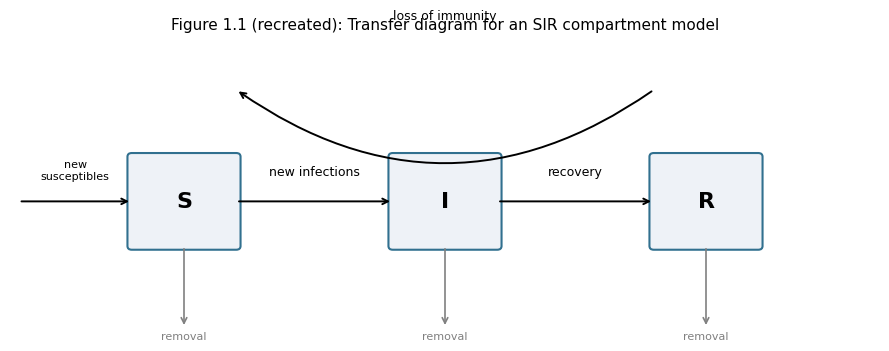

In [1]:
# Recreating the book's Figure 1.1 transfer diagram programmatically
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")

compartments = {"S": 2, "I": 5, "R": 8}
for label, x in compartments.items():
    ax.add_patch(patches.FancyBboxPatch((x-0.6, 1.2), 1.2, 1.2, boxstyle="round,pad=0.05",
                                         fc="#eef2f7", ec="#31708f", lw=1.5))
    ax.text(x, 1.8, label, ha="center", va="center", fontsize=16, fontweight="bold")

def arrow(x0, x1, y, label, curve=0.0):
    ax.annotate("", xy=(x1, y), xytext=(x0, y),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.4,
                                 connectionstyle=f"arc3,rad={curve}"))
    ax.text((x0+x1)/2, y + (0.35 if curve == 0 else 0.9*abs(curve)*3), label,
            ha="center", fontsize=9)

# main chain S -> I -> R
arrow(2.6, 4.4, 1.8, "new infections")
arrow(5.6, 7.4, 1.8, "recovery")
# loss of immunity R -> S (curved, above)
arrow(7.4, 2.6, 3.3, "loss of immunity", curve=-0.35)
# new susceptibles entering S
ax.annotate("", xy=(1.4, 1.8), xytext=(0.1, 1.8), arrowprops=dict(arrowstyle="->", lw=1.4))
ax.text(0.75, 2.1, "new\nsusceptibles", ha="center", fontsize=8)
# removal arrows, straight down, from each compartment
for x in compartments.values():
    ax.annotate("", xy=(x, 0.1), xytext=(x, 1.2), arrowprops=dict(arrowstyle="->", lw=1.2, color="grey"))
    ax.text(x, -0.05, "removal", ha="center", fontsize=8, color="grey")

ax.set_title("Figure 1.1 (recreated): Transfer diagram for an SIR compartment model", fontsize=11)
plt.tight_layout()
plt.savefig("transfer_diagram_1_1.png", dpi=130, bbox_inches="tight")
plt.show()


---
## Block 2 — From bookkeeping to differential equations (the core derivation)

### 1. Rewrite

Let $S(t)$, $I(t)$, $R(t)$ be the number of hosts in each compartment at time $t$. Look at a
short time window $[t, t+\Delta t]$. The **net change** in a compartment over that window equals
(number coming in) minus (number leaving), during that window. Applying this to each compartment:

$$\Delta S(t) = \text{new susceptibles} + \text{transfer from } R - \text{new infections} - \text{removal from } S$$
$$\Delta I(t) = \text{new infections} - \text{transfer into } R - \text{removal from } I$$
$$\Delta R(t) = \text{transfer from } I - \text{transfer into } S - \text{removal from } R$$

Divide every equation by $\Delta t$ and let $\Delta t \to 0$. The left-hand sides become
derivatives $S'(t)$, $I'(t)$, $R'(t)$; the right-hand sides become **instantaneous rates**:

$$S'(t) = \text{influx rate of new susceptibles} + \text{transfer rate from } R - \text{incidence rate} - \text{removal rate from } S$$
$$I'(t) = \text{incidence rate} - \text{transfer rate into } R - \text{removal rate from } I$$
$$R'(t) = \text{transfer rate from } I - \text{transfer rate into } S - \text{removal rate from } R$$

Once every term on the right is written as an explicit function of $S(t)$, $I(t)$, $R(t)$, you get
a genuine system of ODEs — the mathematical model. **How** you write those terms encodes your
biological hypotheses; different hypotheses give different models with different outcomes. If
data exists, you can test whether your hypotheses were right.

### 2. Simplified

Think of the "Can Still Catch It" room (S) as a bathtub. Water (people) flows in through one tap
("new susceptibles") and drains out through several drains ("new infections," "removal"). Over a
short slice of time, the change in water level equals (water flowing in during that slice) minus
(water flowing out during that slice) — that's just common sense bookkeeping. Now here's the
clever trick: if you make that time slice *impossibly short* — like, a blink shrinking to zero —
the "change divided by time" stops being a clunky average and becomes the *exact instantaneous
rate* the water level is changing at that very moment. That instant rate is exactly what a
derivative, $S'(t)$, means. So a differential equation is just "bathtub bookkeeping" taken to the
limit of infinitely short time slices.

### 4. Mathematical Breakdown — step by step derivation

**Step 1 — bookkeeping over a finite interval.** For any compartment, conservation of individuals
over $[t, t+\Delta t]$ gives:
$$\Delta S(t) = S(t+\Delta t) - S(t) = (\text{in-flows during } \Delta t) - (\text{out-flows during } \Delta t)$$
This is just "final minus initial equals net change" — no calculus yet, just counting.

**Step 2 — divide by $\Delta t$.**
$$\frac{\Delta S(t)}{\Delta t} = \frac{S(t+\Delta t) - S(t)}{\Delta t} = \frac{\text{in-flows} - \text{out-flows}}{\Delta t}$$
Dividing both sides by the same nonzero number $\Delta t$ preserves the equation — pure algebra.

**Step 3 — take the limit $\Delta t \to 0$.** The left-hand side is, by the definition of the
derivative,
$$\lim_{\Delta t \to 0} \frac{S(t+\Delta t) - S(t)}{\Delta t} = S'(t).$$
This is literally the definition of a derivative from first-principles calculus — nothing new is
assumed here beyond that definition. On the right-hand side, "(in-flows)/$\Delta t$" stops being a
count over an interval and becomes a **rate** — flows *per unit time*, evaluated at the instant
$t$ (formally, this requires the in/out-flow functions to be differentiable, which the book takes
as an implicit smoothness assumption).

**Step 4 — repeat for $I$ and $R$.** Identical algebra, applied to the other two balance
equations, gives $I'(t)$ and $R'(t)$.

**Step 5 — express rates as functions of state.** The final modeling step — not yet calculus, but
modeling judgment — is to write each rate (incidence rate, recovery rate, removal rate, etc.) as
an explicit function of $S(t)$, $I(t)$, $R(t)$ (and possibly $t$ itself). That choice is where
biology enters the mathematics. Section 1.3 makes this choice concretely.

### 5. Symbols

| Symbol | Meaning | Units | Introduced because... |
|---|---|---|---|
| $S(t), I(t), R(t)$ | Number of hosts in each compartment at time $t$ | people (a count, but treated as a continuous real number — see Sec. 1.1's "deterministic model" assumption) | These are the state variables the whole model tracks |
| $\Delta t$ | Length of a small time window | time (e.g. days) | Needed to go from a snapshot to a *rate* |
| $\Delta S(t), \Delta I(t), \Delta R(t)$ | Net change in each compartment over $[t, t+\Delta t]$ | people | Intermediate bookkeeping quantity, before taking the limit |
| $S'(t), I'(t), R'(t)$ | Instantaneous rate of change of each compartment | people per unit time | What the differential equations are equations *for* |

### 6. Mathematical Intuition

The derivation is really answering: **"why differential equations, and not just arithmetic?"**
Arithmetic bookkeeping ($\Delta S = \text{in} - \text{out}$) only tells you the *net* change over
a whole time chunk — during that chunk, the rates of infection/recovery might themselves have been
changing (e.g. as $S(t)$ falls, new infections should slow down). By shrinking the chunk to zero,
you capture the *instantaneous* rate at every single moment, which is what lets the model respond
continuously and self-consistently as the epidemic evolves — a $\Delta t = 1\text{ day}$
bookkeeping model would be a coarse approximation; the ODE is the "infinitely fine-grained"
version of the exact same idea.


In [2]:
# A symbolic + numerical check that the limiting process really does what the
# text claims: (S(t+dt) - S(t)) / dt -> S'(t) as dt -> 0, for a CONCRETE choice
# of S(t), so we are not just taking the book's word for it.
import sympy as sp

t, dt = sp.symbols('t dt', positive=True)

# Pick a concrete, non-trivial S(t) -- e.g. a plausible "declining susceptibles" curve.
S_expr = 1000 * sp.exp(-0.05 * t) + 50 * sp.cos(t)   # arbitrary smooth example function

difference_quotient = (S_expr.subs(t, t + dt) - S_expr) / dt
limit_result = sp.limit(difference_quotient, dt, 0)
derivative_direct = sp.diff(S_expr, t)

print("S(t)                         =", S_expr)
print("Difference quotient (Δt)     =", sp.simplify(difference_quotient))
print("limit as Δt -> 0             =", sp.simplify(limit_result))
print("d/dt S(t) computed directly  =", sp.simplify(derivative_direct))
print("\nMatch:", sp.simplify(limit_result - derivative_direct) == 0)


S(t)                         = 50*cos(t) + 1000*exp(-0.05*t)


Difference quotient (Δt)     = 1000*exp(-0.05*dt - 0.05*t)/dt - 50*cos(t)/dt + 50*cos(dt + t)/dt - 1000*exp(-0.05*t)/dt
limit as Δt -> 0             = -50*sin(t) - 50*exp(-t/20)
d/dt S(t) computed directly  = -50.0*sin(t) - 50.0*exp(-0.05*t)

Match: True


In [3]:
# Numerically: does the difference quotient visibly converge to the true derivative
# as we shrink dt? This makes Step 3 of the derivation concrete and checkable.
import numpy as np

S_func = lambda tt: 1000*np.exp(-0.05*tt) + 50*np.cos(tt)
Sprime_true = lambda tt: -50*np.exp(-0.05*tt) - 50*np.sin(tt)

t0 = 5.0
true_deriv = Sprime_true(t0)

print(f"{'Δt':>10} | {'difference quotient':>20} | {'error vs true derivative':>25}")
for dt_val in [1.0, 0.1, 0.01, 0.001, 0.0001]:
    dq = (S_func(t0 + dt_val) - S_func(t0)) / dt_val
    print(f"{dt_val:10.4f} | {dq:20.6f} | {abs(dq - true_deriv):25.8f}")

print(f"\nTrue derivative S'({t0}) = {true_deriv:.6f}")
print("As Δt shrinks, the difference quotient converges to the true derivative -- exactly Step 3.")


        Δt |  difference quotient |  error vs true derivative
    1.0000 |            -4.157157 |               13.16333191
    0.1000 |             8.314928 |                0.69124706
    0.0100 |             8.944194 |                0.06198067
    0.0010 |             9.000049 |                0.00612606
    0.0001 |             9.005563 |                0.00061188

True derivative S'(5.0) = 9.006175
As Δt shrinks, the difference quotient converges to the true derivative -- exactly Step 3.


### 10. Verification

Both the symbolic (SymPy `limit`) and numerical (shrinking $\Delta t$) checks confirm the
book's central claim of this section: the "difference quotient → derivative as $\Delta t \to 0$"
step is not a hand-wave, it is literally the textbook definition of a derivative, and it holds for
an arbitrary smooth function, not just some special case.

### 7. Visual Understanding


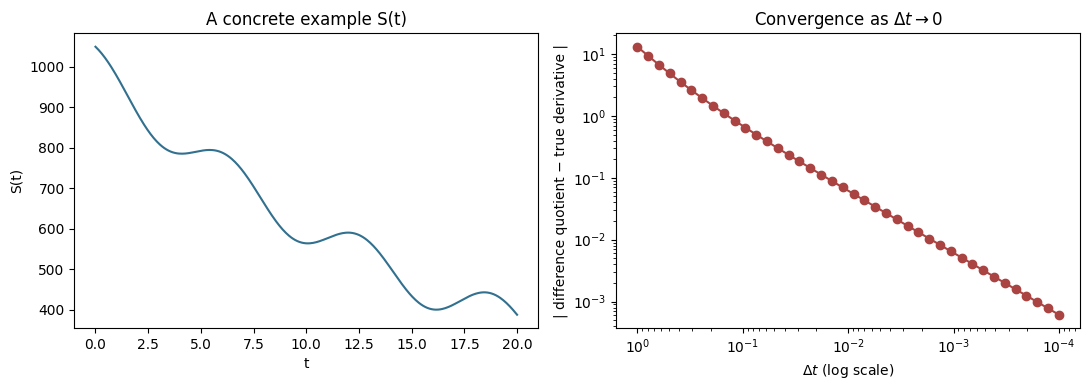

In [4]:
import matplotlib.pyplot as plt
import numpy as np

t_grid = np.linspace(0, 20, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(t_grid, S_func(t_grid), color="#31708f")
axes[0].set_title("A concrete example S(t)")
axes[0].set_xlabel("t"); axes[0].set_ylabel("S(t)")

dts = np.logspace(0, -4, 40)
errors = [abs((S_func(t0+d) - S_func(t0))/d - true_deriv) for d in dts]
axes[1].loglog(dts, errors, marker="o", color="#a94442")
axes[1].set_xlabel(r"$\Delta t$ (log scale)")
axes[1].set_ylabel("| difference quotient − true derivative |")
axes[1].set_title(r"Convergence as $\Delta t \to 0$")
axes[1].invert_xaxis()

plt.tight_layout()
plt.savefig("difference_quotient_convergence.png", dpi=130, bbox_inches="tight")
plt.show()


---
## Summary

**One sentence:** Every compartmental epidemic model in this book is built by writing an exact
bookkeeping equation (in-flow minus out-flow) for each compartment over a short time window, then
taking the limit as that window shrinks to zero to get a system of ordinary differential
equations, whose right-hand sides are then filled in according to specific biological hypotheses.

**One paragraph:** The population is partitioned into disease-status compartments (here S, I, R),
visualized with a transfer diagram whose arrows represent movement between compartments. Applying
basic conservation ("change = in minus out") to each compartment over a small interval
$[t, t+\Delta t]$, dividing by $\Delta t$, and taking the limit $\Delta t \to 0$ converts discrete
bookkeeping into a system of differential equations $S'(t), I'(t), R'(t)$ whose terms are
*instantaneous rates* rather than interval totals. The actual functional form of each rate term
(how incidence, recovery, and removal depend on $S$, $I$, $R$) is not determined by this limiting
process — it is a separate modeling choice, driven by biological hypotheses, and that choice is
exactly what Section 1.3 makes concrete for a first classic model.

**Bullet points:**
- Transfer diagrams are the direct visual precursor to the ODE terms.
- Net change = in-flow − out-flow, applied over $[t, t+\Delta t]$, is pure bookkeeping (no calculus yet).
- Dividing by $\Delta t$ and taking the limit $\Delta t \to 0$ is exactly the definition of a derivative — verified here both symbolically and numerically.
- The resulting ODE system's *structure* (that it's a system of derivatives) is generic; its *content* (what each rate term looks like) depends entirely on modeling hypotheses, made explicit in Sec. 1.3.

## Memory Aids

- **Mnemonic**: "Change = In − Out, then shrink the clock." That's the whole derivation in six words.
- **Mental model**: bathtub with taps (inflows) and drains (outflows); $S'(t)$ is the *instantaneous*
  net flow rate, not the *net change over a day*.
- **Common mistake**: writing $\Delta S/\Delta t$ once and forgetting to actually take
  $\Delta t \to 0$ — a difference quotient is *not* the same object as a derivative, it's only an
  approximation to it (see the convergence plot above — the error is nonzero for any finite $\Delta t$).
- **Exam tip**: if asked to "derive the SIR equations from first principles," this five-step
  process (bookkeeping → divide by $\Delta t$ → take the limit → repeat for each compartment →
  substitute rate functions) is exactly what's expected, in this order.

## Connections

- **← Section 1.1**: this section is the direct mathematical translation of Stage 2 ("build the
  model") in the six-stage modeling loop from Sec. 1.1.
- **→ Section 1.3**: fills in the abstract rate terms here (incidence rate, recovery rate, etc.)
  with concrete functions of $S, I, R$ for the Kermack–McKendrick model.
- **→ Section 1.4**: examines *why* particular functional forms (like $\lambda I(t)S(t)$ for
  incidence) are reasonable, revisiting exactly the "how do we express rates as functions of
  state" step from this section.
- **→ Calculus**: this is a direct, applied instance of the definition of the derivative as a
  limit of a difference quotient — the same definition taught in any first calculus course,
  applied here to population counts instead of abstract $x$/$y$.
- **→ Physics/Engineering**: identical derivation pattern to deriving conservation laws (e.g. mass
  balance in fluid dynamics, charge conservation in circuits) — "rate of accumulation = rate in −
  rate out" is a near-universal modeling principle across science and engineering.

*Practice problems for this section are in `../../chapter_01/exercises/section_1_2_exercises.md`, with full
worked solutions in `../../chapter_01/solutions/section_1_2_solutions.md`.*
